# Importación de librerias, leer dataframes y concatenarlos

In [477]:
import pandas as pd
import os
from glob import glob

ruta = r"C:\Users\jorge\OneDrive\Documentos\MASTER\TFM\modelo"

# Leer LaLiga_Matches.csv
resultados = pd.read_csv(os.path.join(ruta, "LaLiga_Matches_completo.csv"))

# Comprobar
print(resultados.shape)
resultados.head()


(11944, 10)


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,2.0,0.0,H
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3.0,0.0,H
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,2.0,0.0,H
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,1.0,1.0,D
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0.0,0.0,D


In [478]:
resultados = resultados[resultados["Season"] >= "2016-17"]

print(resultados.shape)
resultados[resultados["Season"] == "2016-17"].head(500)

(3800, 10)


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
8144,2016-17,19-08-2016,La Coruna,Eibar,2,1,H,0.0,0.0,D
8145,2016-17,19-08-2016,Malaga,Osasuna,1,1,D,0.0,0.0,D
8146,2016-17,20-08-2016,Barcelona,Betis,6,2,H,3.0,1.0,H
8147,2016-17,20-08-2016,Granada,Villarreal,1,1,D,0.0,0.0,D
8148,2016-17,20-08-2016,Sevilla,Espanol,6,4,H,3.0,3.0,D
...,...,...,...,...,...,...,...,...,...,...
8519,2016-17,21-05-2017,Ath Madrid,Ath Bilbao,3,1,H,2.0,0.0,H
8520,2016-17,21-05-2017,Barcelona,Eibar,4,2,H,0.0,1.0,A
8521,2016-17,21-05-2017,Celta,Sociedad,2,2,D,0.0,0.0,D
8522,2016-17,21-05-2017,Malaga,Real Madrid,0,2,A,0.0,1.0,A


In [479]:
import pandas as pd
import os
from glob import glob

ruta = r"C:\Users\jorge\OneDrive\Documentos\MASTER\TFM\modelo"


dfs = []

for archivo in glob(os.path.join(ruta, "resumen_*.csv")):
    año = os.path.basename(archivo).replace("resumen_", "").replace(".csv", "")
    
    df = pd.read_csv(archivo,sep=";")
    df["temporada"] = año
    
    dfs.append(df)

clasificacion = pd.concat(dfs, ignore_index=True)
clasificacion["temporada"] = clasificacion["temporada"].astype(int).apply(
    lambda x: f"{x}-{str(x+1)[-2:]}"
)
clasificacion_prev = clasificacion.copy()

clasificacion_prev["Season"] = clasificacion_prev["temporada"].apply(
    lambda x: f"{int(x[:4])+1}-{str(int(x[:4])+2)[-2:]}"
)

clasificacion_prev.head()




,number,team,matches,wins,draws,loses,goals,ga,points,xG,xGA,xPTS,temporada,Season
0,1,Barcelona,38,29,4,5,112,29,91,113.60,34.03,94.38,2015-16,2016-17
1,2,Real Madrid,38,28,6,4,110,34,90,90.45,45.23,79.09,2015-16,2016-17
2,3,Atletico Madrid,38,28,4,6,63,18,88,54.93,27.80,72.28,2015-16,2016-17
3,4,Villarreal,38,18,10,10,44,35,64,40.49,41.63,52.11,2015-16,2016-17
4,5,Athletic Club,38,18,8,12,58,45,62,53.90,45.33,58.24,2015-16,2016-17


# Preparamos los dataframes y los unimos

In [480]:
equipos = {
    "Ath Madrid": "Atletico Madrid",
    "Ath Bilbao": "Athletic Club",
    "Celta": "Celta Vigo",
    "Sociedad": "Real Sociedad",
    "La Coruna": "Deportivo La Coruna",
    "Sp Gijon": "Sporting Gijon",
    "Betis": "Real Betis",
    "Vallecano": "Rayo Vallecano",
    "Alaves": "Alaves",
    "Espanol": "Espanyol",
    "Huesca": "SD Huesca",
    "Oviedo": "Real Oviedo",
    "Valladolid": "Real Valladolid",
    "Villareal": "Villarreal",
}

resultados["HomeTeam"] = resultados["HomeTeam"].replace(equipos)
resultados["AwayTeam"] = resultados["AwayTeam"].replace(equipos)

In [481]:
resultados.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
8144,2016-17,19-08-2016,Deportivo La Coruna,Eibar,2,1,H,0.0,0.0,D
8145,2016-17,19-08-2016,Malaga,Osasuna,1,1,D,0.0,0.0,D
8146,2016-17,20-08-2016,Barcelona,Real Betis,6,2,H,3.0,1.0,H
8147,2016-17,20-08-2016,Granada,Villarreal,1,1,D,0.0,0.0,D
8148,2016-17,20-08-2016,Sevilla,Espanyol,6,4,H,3.0,3.0,D


In [482]:
clasificacion_home = clasificacion_prev.rename(
    columns=lambda c: f"HomeTeam_{c}" if c not in ["Season"] else c
)

clasificacion_home = clasificacion_home.rename(
    columns={"HomeTeam_team": "HomeTeam"}
)
clasificacion_home.head()

,HomeTeam_number,HomeTeam,HomeTeam_matches,HomeTeam_wins,HomeTeam_draws,HomeTeam_loses,HomeTeam_goals,HomeTeam_ga,HomeTeam_points,HomeTeam_xG,HomeTeam_xGA,HomeTeam_xPTS,HomeTeam_temporada,Season
0,1,Barcelona,38,29,4,5,112,29,91,113.60,34.03,94.38,2015-16,2016-17
1,2,Real Madrid,38,28,6,4,110,34,90,90.45,45.23,79.09,2015-16,2016-17
2,3,Atletico Madrid,38,28,4,6,63,18,88,54.93,27.80,72.28,2015-16,2016-17
3,4,Villarreal,38,18,10,10,44,35,64,40.49,41.63,52.11,2015-16,2016-17
4,5,Athletic Club,38,18,8,12,58,45,62,53.90,45.33,58.24,2015-16,2016-17


In [485]:
# Unir
resultados = resultados.merge(
    clasificacion_home,
    on=["Season", "HomeTeam"],
    how="left"
)
clasificacion_away = clasificacion_prev.rename(
    columns=lambda c: f"AwayTeam_{c}" if c not in ["Season"] else c
)

clasificacion_away = clasificacion_away.rename(
    columns={"AwayTeam_team": "AwayTeam"}
)

resultados = resultados.merge(
    clasificacion_away,
    on=["Season", "AwayTeam"],
    how="left"
)
resultados.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AwayTeam_wins,AwayTeam_draws,AwayTeam_loses,AwayTeam_goals,AwayTeam_ga,AwayTeam_points,AwayTeam_xG,AwayTeam_xGA,AwayTeam_xPTS,AwayTeam_temporada
0,2016-17,19-08-2016,Deportivo La Coruna,Eibar,2,1,H,0.0,0.0,D,...,11.0,10.0,17.0,49.0,61.0,43.0,52.92,50.58,54.03,2015-16
1,2016-17,19-08-2016,Malaga,Osasuna,1,1,D,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-17,20-08-2016,Barcelona,Real Betis,6,2,H,3.0,1.0,H,...,11.0,12.0,15.0,34.0,52.0,45.0,40.11,64.39,40.49,2015-16
3,2016-17,20-08-2016,Granada,Villarreal,1,1,D,0.0,0.0,D,...,18.0,10.0,10.0,44.0,35.0,64.0,40.49,41.63,52.11,2015-16
4,2016-17,20-08-2016,Sevilla,Espanyol,6,4,H,3.0,3.0,D,...,12.0,7.0,19.0,40.0,74.0,43.0,46.09,60.84,43.15,2015-16


# Del dataframe final, selección de variables y creamos nuevas variables

In [486]:
resultados.columns

Index(['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR', 'HomeTeam_number', 'HomeTeam_matches', 'HomeTeam_wins',
       'HomeTeam_draws', 'HomeTeam_loses', 'HomeTeam_goals', 'HomeTeam_ga',
       'HomeTeam_points', 'HomeTeam_xG', 'HomeTeam_xGA', 'HomeTeam_xPTS',
       'HomeTeam_temporada', 'AwayTeam_number', 'AwayTeam_matches',
       'AwayTeam_wins', 'AwayTeam_draws', 'AwayTeam_loses', 'AwayTeam_goals',
       'AwayTeam_ga', 'AwayTeam_points', 'AwayTeam_xG', 'AwayTeam_xGA',
       'AwayTeam_xPTS', 'AwayTeam_temporada'],
      dtype='object')

In [487]:
# 1. Eliminar columnas que no vamos a utilizar
resultados = resultados.drop(
    columns=["HomeTeam_matches","AwayTeam_matches", "FTR", "HTR"],
    errors="ignore"
)

# 2. Crear diferencia de goles final
resultados["diferencia_goles"] = (
    resultados["FTHG"] - resultados["FTAG"]
)

# 3. Crear diferencia de goles al descanso
resultados["diferencia_goles_descanso"] = (
    resultados["HTHG"] - resultados["HTAG"]
)

# 4. Eliminar las columnas originales si ya no las necesitas
resultados = resultados.drop(
    columns=["FTHG", "FTAG", "HTHG", "HTAG"]
)

# 5. Renombrar columnas al español
resultados = resultados.rename(columns={
    "Season": "temporada",
    "Date": "fecha",
    "HomeTeam": "equipo_local",
    "AwayTeam": "equipo_visitante",

    "HomeTeam_number": "clasificacion_local",
    "HomeTeam_wins": "victorias_local",
    "HomeTeam_draws": "empates_local",
    "HomeTeam_loses": "derrotas_local",
    "HomeTeam_goals": "goles_local_temp_anterior",
    "HomeTeam_ga": "goles_contra_local_temp_anterior",
    "HomeTeam_points": "puntos_local_temp_anterior",
    "HomeTeam_xG": "xg_local_temp_anterior",
    "HomeTeam_xGA": "xga_local_temp_anterior",
    "HomeTeam_xPTS": "xpts_local_temp_anterior",
    "HomeTeam_temporada": "temporada_local_anterior",

    "AwayTeam_number": "clasificacion_visitante",
    "AwayTeam_wins": "victorias_visitante",
    "AwayTeam_draws": "empates_visitante",
    "AwayTeam_loses": "derrotas_visitante",
    "AwayTeam_goals": "goles_visitante_temp_anterior",
    "AwayTeam_ga": "goles_contra_visitante_temp_anterior",
    "AwayTeam_points": "puntos_visitante_temp_anterior",
    "AwayTeam_xG": "xg_visitante_temp_anterior",
    "AwayTeam_xGA": "xga_visitante_temp_anterior",
    "AwayTeam_xPTS": "xpts_visitante_temp_anterior",
    "AwayTeam_temporada": "temporada_visitante_anterior"
})

# Comprobar resultado
resultados.head()

,temporada,fecha,equipo_local,equipo_visitante,clasificacion_local,victorias_local,empates_local,derrotas_local,goles_local_temp_anterior,goles_contra_local_temp_anterior,...,derrotas_visitante,goles_visitante_temp_anterior,goles_contra_visitante_temp_anterior,puntos_visitante_temp_anterior,xg_visitante_temp_anterior,xga_visitante_temp_anterior,xpts_visitante_temp_anterior,temporada_visitante_anterior,diferencia_goles,diferencia_goles_descanso
0,2016-17,19-08-2016,Deportivo La Coruna,Eibar,15.0,8.0,18.0,12.0,45.0,61.0,...,17.0,49.0,61.0,43.0,52.92,50.58,54.03,2015-16,1,0.0
1,2016-17,19-08-2016,Malaga,Osasuna,8.0,12.0,12.0,14.0,38.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
2,2016-17,20-08-2016,Barcelona,Real Betis,1.0,29.0,4.0,5.0,112.0,29.0,...,15.0,34.0,52.0,45.0,40.11,64.39,40.49,2015-16,4,2.0
3,2016-17,20-08-2016,Granada,Villarreal,17.0,10.0,9.0,19.0,46.0,69.0,...,10.0,44.0,35.0,64.0,40.49,41.63,52.11,2015-16,0,0.0
4,2016-17,20-08-2016,Sevilla,Espanyol,7.0,14.0,10.0,14.0,51.0,50.0,...,19.0,40.0,74.0,43.0,46.09,60.84,43.15,2015-16,2,0.0


In [488]:
resultados.isna().sum()

temporada                                 0
fecha                                     0
equipo_local                              0
equipo_visitante                          0
clasificacion_local                     570
victorias_local                         570
empates_local                           570
derrotas_local                          570
goles_local_temp_anterior               570
goles_contra_local_temp_anterior        570
puntos_local_temp_anterior              570
xg_local_temp_anterior                  570
xga_local_temp_anterior                 570
xpts_local_temp_anterior                570
temporada_local_anterior                570
clasificacion_visitante                 570
victorias_visitante                     570
empates_visitante                       570
derrotas_visitante                      570
goles_visitante_temp_anterior           570
goles_contra_visitante_temp_anterior    570
puntos_visitante_temp_anterior          570
xg_visitante_temp_anterior      

In [489]:
resultados=resultados.dropna()

In [490]:
resultados.columns

Index(['temporada', 'fecha', 'equipo_local', 'equipo_visitante',
       'clasificacion_local', 'victorias_local', 'empates_local',
       'derrotas_local', 'goles_local_temp_anterior',
       'goles_contra_local_temp_anterior', 'puntos_local_temp_anterior',
       'xg_local_temp_anterior', 'xga_local_temp_anterior',
       'xpts_local_temp_anterior', 'temporada_local_anterior',
       'clasificacion_visitante', 'victorias_visitante', 'empates_visitante',
       'derrotas_visitante', 'goles_visitante_temp_anterior',
       'goles_contra_visitante_temp_anterior',
       'puntos_visitante_temp_anterior', 'xg_visitante_temp_anterior',
       'xga_visitante_temp_anterior', 'xpts_visitante_temp_anterior',
       'temporada_visitante_anterior', 'diferencia_goles',
       'diferencia_goles_descanso'],
      dtype='object')

# EDA

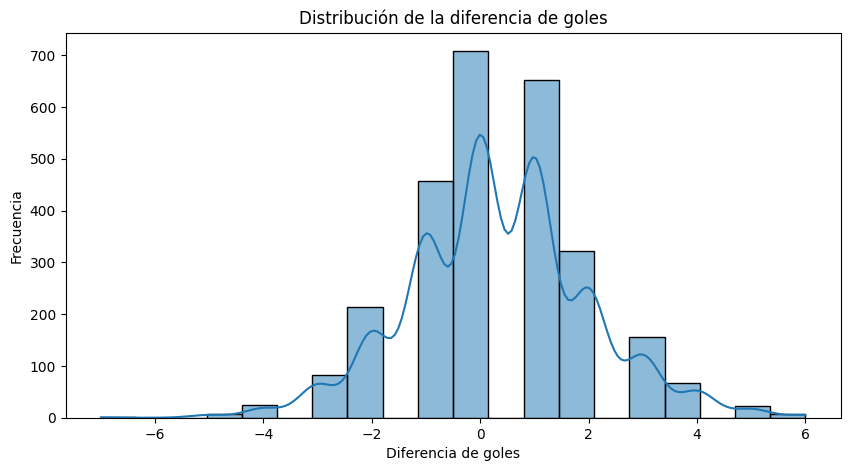

In [491]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(resultados["diferencia_goles"], bins=20, kde=True)

plt.title("Distribución de la diferencia de goles")
plt.xlabel("Diferencia de goles")
plt.ylabel("Frecuencia")
plt.show()

In [492]:
variables = [
    "clasificacion_local",
    "clasificacion_visitante",
    "puntos_local_temp_anterior",
    "puntos_visitante_temp_anterior",
    "xg_local_temp_anterior",
    "xg_visitante_temp_anterior",
    "xpts_local_temp_anterior",
    "xpts_visitante_temp_anterior"
]

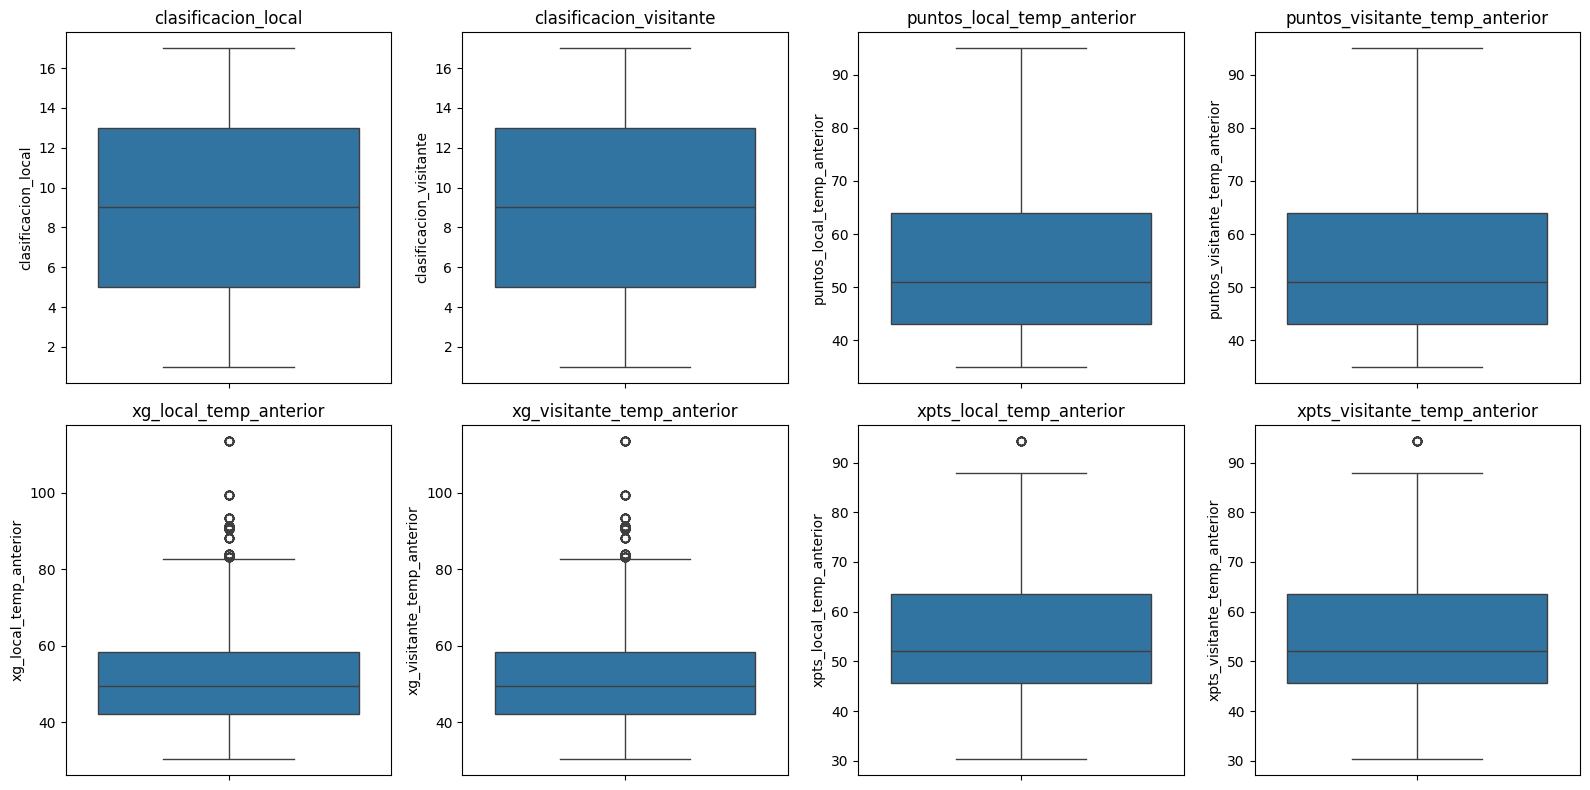

In [493]:
fig, axes = plt.subplots(2,4, figsize=(16,8))

for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(y=resultados[var], ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

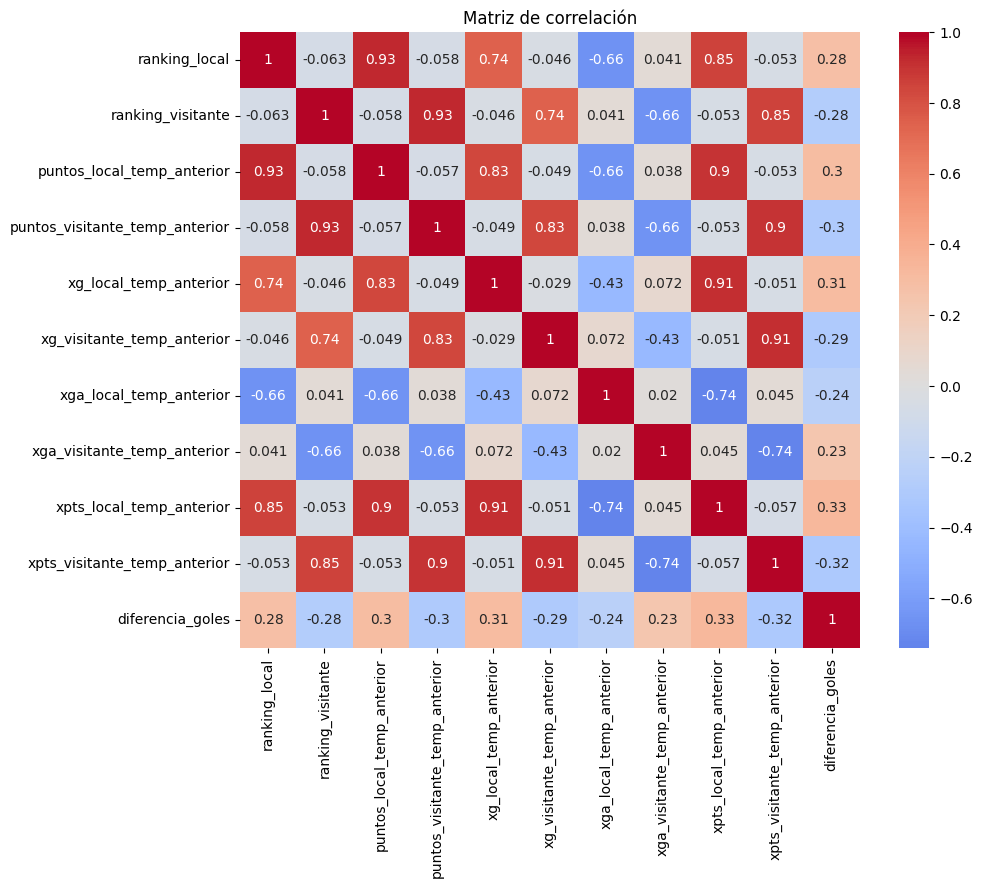

In [494]:
import numpy as np
resultados["ranking_local"] = 21 - resultados["clasificacion_local"]
resultados["ranking_visitante"] = 21 - resultados["clasificacion_visitante"]

corr_vars = [
    "ranking_local",
    "ranking_visitante",
    "puntos_local_temp_anterior",
    "puntos_visitante_temp_anterior",
    "xg_local_temp_anterior",
    "xg_visitante_temp_anterior",
    "xga_local_temp_anterior",
    "xga_visitante_temp_anterior",
    "xpts_local_temp_anterior",
    "xpts_visitante_temp_anterior",
    "diferencia_goles"
]

corr = resultados[corr_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")
plt.show()

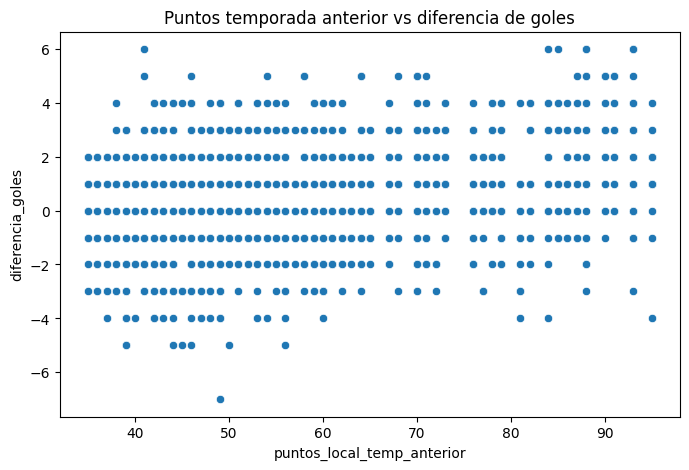

In [495]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=resultados,
    x="puntos_local_temp_anterior",
    y="diferencia_goles"
)

plt.title("Puntos temporada anterior vs diferencia de goles")
plt.show()

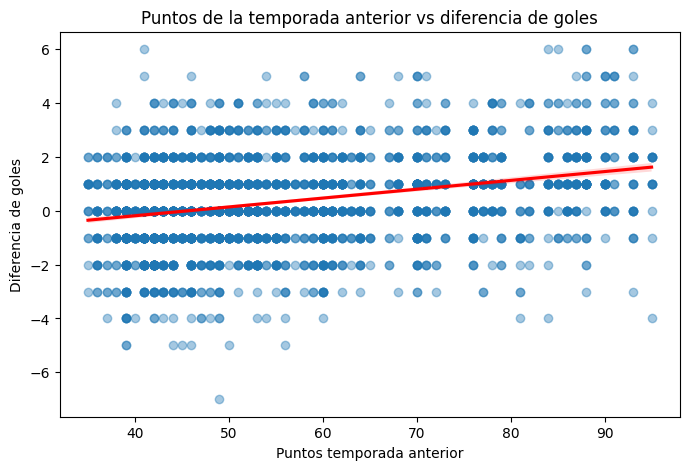

In [496]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.regplot(
    data=resultados,
    x="puntos_local_temp_anterior",
    y="diferencia_goles",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Puntos de la temporada anterior vs diferencia de goles")
plt.xlabel("Puntos temporada anterior")
plt.ylabel("Diferencia de goles")
plt.show()


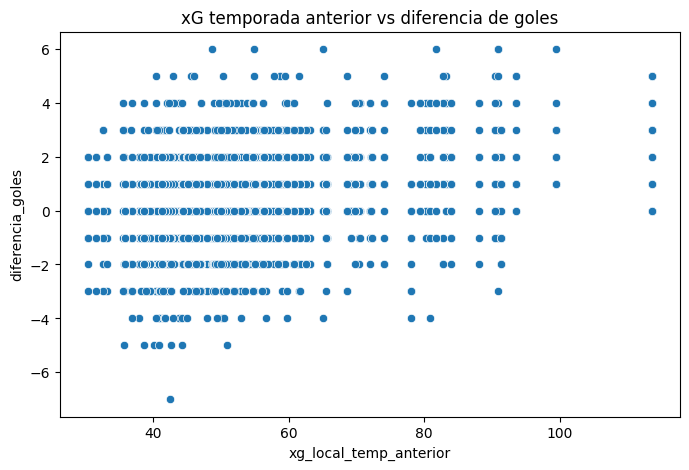

In [497]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=resultados,
    x="xg_local_temp_anterior",
    y="diferencia_goles"
)

plt.title("xG temporada anterior vs diferencia de goles")
plt.show()

In [498]:
resultados.shape

(2720, 30)

# MODELO: librerias, nuevas variables, division..

In [499]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [500]:
df_modelo = resultados.copy()

df_modelo["ranking_local"] = 21 - df_modelo["clasificacion_local"]
df_modelo["ranking_visitante"] = 21 - df_modelo["clasificacion_visitante"]

df_modelo["dif_ranking"] = df_modelo["ranking_local"] - df_modelo["ranking_visitante"]
df_modelo["dif_puntos"] = df_modelo["puntos_local_temp_anterior"] - df_modelo["puntos_visitante_temp_anterior"]
df_modelo["dif_xg"] = df_modelo["xg_local_temp_anterior"] - df_modelo["xg_visitante_temp_anterior"]
df_modelo["dif_xga"] = df_modelo["xga_local_temp_anterior"] - df_modelo["xga_visitante_temp_anterior"]
df_modelo["dif_xpts"] = df_modelo["xpts_local_temp_anterior"] - df_modelo["xpts_visitante_temp_anterior"]
df_modelo["dif_goles_temp_anterior"] = df_modelo["goles_local_temp_anterior"] - df_modelo["goles_visitante_temp_anterior"]
df_modelo["dif_goles_contra_temp_anterior"] = df_modelo["goles_contra_local_temp_anterior"] - df_modelo["goles_contra_visitante_temp_anterior"]

In [501]:
def crear_resultado(x):
    if x > 0:
        return "Victoria local"
    elif x < 0:
        return "Victoria visitante"
    else:
        return "Empate"

df_modelo["resultado"] = df_modelo["diferencia_goles"].apply(crear_resultado)

In [502]:
features = [
    "ranking_local",
    "ranking_visitante",
    "puntos_local_temp_anterior",
    "puntos_visitante_temp_anterior",
    "xg_local_temp_anterior",
    "xg_visitante_temp_anterior",
    "xga_local_temp_anterior",
    "xga_visitante_temp_anterior",
    "xpts_local_temp_anterior",
    "xpts_visitante_temp_anterior",
    "goles_local_temp_anterior",
    "goles_visitante_temp_anterior",
    "goles_contra_local_temp_anterior",
    "goles_contra_visitante_temp_anterior",
    "dif_ranking",
    "dif_puntos",
    "dif_xg",
    "dif_xga",
    "dif_xpts",
    "dif_goles_temp_anterior",
    "dif_goles_contra_temp_anterior"
]

target = "resultado"

In [503]:
df_modelo = df_modelo.dropna(subset=features + [target])

train = df_modelo[df_modelo["temporada"] != "2025-26"].copy()
test = df_modelo[df_modelo["temporada"] == "2025-26"].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2448, 21)
Test: (272, 21)


In [504]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [505]:
modelos_clasificacion = {

    "Regresión logística": GridSearchCV(
        LogisticRegression(
            max_iter=5000,
            multi_class="multinomial"
        ),
        param_grid={
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["lbfgs"]
        },
        cv=5,
        scoring="accuracy"
    ),

    "Árbol de decisión": GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        param_grid={
            "max_depth": [2, 3, 4, 5, 6, 8, 10],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10]
        },
        cv=5,
        scoring="accuracy"
    ),

    "Random Forest": GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid={
            "n_estimators": [100, 200, 300],
            "max_depth": [3, 5, 8, None],
            "min_samples_leaf": [1, 3, 5],
            "min_samples_split": [2, 5, 10]
        },
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    ),

    "Gradient Boosting": GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid={
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3, 4]
        },
        cv=5,
        scoring="accuracy"
    )
}

In [506]:
resultados_modelos = []

for nombre, modelo in modelos_clasificacion.items():

    if nombre == "Regresión logística":
        modelo.fit(X_train_scaled, y_train)
        pred = modelo.predict(X_test_scaled)

    else:
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)

    resultados_modelos.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "f1_weighted": f1_score(y_test, pred, average="weighted")
    })

tabla_resultados = pd.DataFrame(resultados_modelos).sort_values(
    "accuracy",
    ascending=False
)

tabla_resultados

C:\Users\jorge\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\jorge\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\jorge\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

,modelo,accuracy,f1_macro,f1_weighted
0,Regresión logística,0.522059,0.381314,0.461641
2,Random Forest,0.514706,0.387273,0.462725
3,Gradient Boosting,0.507353,0.352427,0.435005
1,Árbol de decisión,0.503676,0.428676,0.486347


In [507]:
for nombre, modelo in modelos_clasificacion.items():
    print("="*50)
    print(nombre)
    print(modelo.best_params_)
    print()

Regresión logística
{'C': 1, 'solver': 'lbfgs'}

Árbol de decisión
{'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}

Random Forest
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Gradient Boosting
{'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}



In [508]:
mejor_modelo_nombre = tabla_resultados.iloc[0]["modelo"]
mejor_modelo = modelos_clasificacion[mejor_modelo_nombre]

if mejor_modelo_nombre == "Regresión logística":
    probs = mejor_modelo.predict_proba(X_test_scaled)
    pred_final = mejor_modelo.predict(X_test_scaled)
else:
    probs = mejor_modelo.predict_proba(X_test)
    pred_final = mejor_modelo.predict(X_test)

clases = mejor_modelo.best_estimator_.classes_

tabla_probs = pd.DataFrame(
    probs,
    columns=[f"prob_{clase}" for clase in clases]
)

predicciones = test[[
    "temporada",
    "fecha",
    "equipo_local",
    "equipo_visitante",
    "resultado"
]].reset_index(drop=True)

predicciones = pd.concat([predicciones, tabla_probs], axis=1)

predicciones["resultado_predicho"] = pred_final

predicciones.head(20)

,temporada,fecha,equipo_local,equipo_visitante,resultado,prob_Empate,prob_Victoria local,prob_Victoria visitante,resultado_predicho
0,2025-26,15-08-2025,Girona,Rayo Vallecano,Victoria visitante,0.315361,0.425688,0.258950,Victoria local
1,2025-26,16-08-2025,Mallorca,Barcelona,Victoria visitante,0.224329,0.095025,0.680646,Victoria visitante
2,2025-26,16-08-2025,Valencia,Real Sociedad,Empate,0.335779,0.388385,0.275836,Victoria local
3,2025-26,17-08-2025,Celta Vigo,Getafe,Victoria visitante,0.251637,0.587012,0.161351,Victoria local
4,2025-26,17-08-2025,Athletic Club,Sevilla,Victoria local,0.265586,0.604679,0.129735,Victoria local
5,2025-26,17-08-2025,Espanyol,Atletico Madrid,Victoria local,0.333534,0.128326,0.538140,Victoria visitante
6,2025-26,19-08-2025,Real Madrid,Osasuna,Victoria local,0.152459,0.760520,0.087022,Victoria local
7,2025-26,22-08-2025,Real Betis,Alaves,Victoria local,0.265677,0.556401,0.177922,Victoria local
8,2025-26,23-08-2025,Mallorca,Celta Vigo,Empate,0.284841,0.321458,0.393701,Victoria visitante
9,2025-26,24-08-2025,Osasuna,Valencia,Victoria local,0.278690,0.428410,0.292900,Victoria local


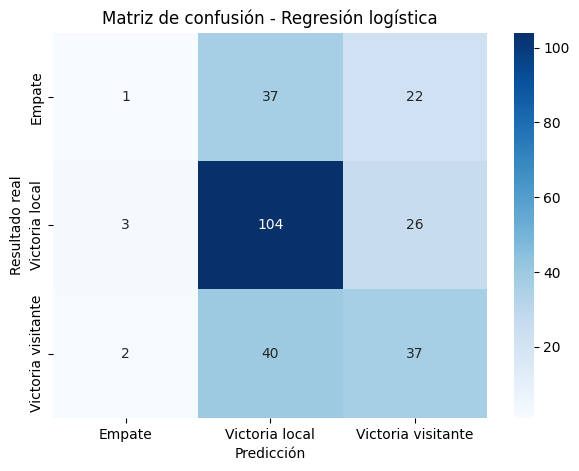

In [509]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_final, labels=clases)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=clases,
    yticklabels=clases,
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Resultado real")
plt.title(f"Matriz de confusión - {mejor_modelo_nombre}")

plt.show()

In [510]:
print(classification_report(y_test, pred_final))

                    precision    recall  f1-score   support

            Empate       0.17      0.02      0.03        60
    Victoria local       0.57      0.78      0.66       133
Victoria visitante       0.44      0.47      0.45        79

          accuracy                           0.52       272
         macro avg       0.39      0.42      0.38       272
      weighted avg       0.44      0.52      0.46       272



# PREDICCION 2025 - 26

In [520]:
import pandas as pd
import numpy as np

# Leer clasificación 2025-26
clasif_base = pd.read_csv(r"C:\Users\jorge\OneDrive\Documentos\MASTER\TFM\modelo\resumen_2026.csv", sep=";")

# Generar calendario completo: todos contra todos ida y vuelta
equipos = clasif_base["team"].unique()

partidos_futuros = pd.DataFrame([
    {"equipo_local": local, "equipo_visitante": visitante}
    for local in equipos
    for visitante in equipos
    if local != visitante
])

partidos_futuros["temporada"] = "2026-27"

In [521]:
# Preparar datos del equipo local
home = clasif_base.rename(columns={
    "number": "clasificacion_local",
    "team": "equipo_local",
    "wins": "victorias_local",
    "draws": "empates_local",
    "loses": "derrotas_local",
    "goals": "goles_local_temp_anterior",
    "ga": "goles_contra_local_temp_anterior",
    "points": "puntos_local_temp_anterior",
    "xG": "xg_local_temp_anterior",
    "xGA": "xga_local_temp_anterior",
    "xPTS": "xpts_local_temp_anterior"
})

home = home.drop(columns=["matches"], errors="ignore")

# Preparar datos del equipo visitante
away = clasif_base.rename(columns={
    "number": "clasificacion_visitante",
    "team": "equipo_visitante",
    "wins": "victorias_visitante",
    "draws": "empates_visitante",
    "loses": "derrotas_visitante",
    "goals": "goles_visitante_temp_anterior",
    "ga": "goles_contra_visitante_temp_anterior",
    "points": "puntos_visitante_temp_anterior",
    "xG": "xg_visitante_temp_anterior",
    "xGA": "xga_visitante_temp_anterior",
    "xPTS": "xpts_visitante_temp_anterior"
})

away = away.drop(columns=["matches"], errors="ignore")

In [522]:
# Unir estadísticas al calendario
partidos_futuros = partidos_futuros.merge(
    home,
    on="equipo_local",
    how="left"
)

partidos_futuros = partidos_futuros.merge(
    away,
    on="equipo_visitante",
    how="left"
)

In [523]:
# Crear rankings
partidos_futuros["ranking_local"] = 21 - partidos_futuros["clasificacion_local"]
partidos_futuros["ranking_visitante"] = 21 - partidos_futuros["clasificacion_visitante"]

# Crear variables diferenciales
partidos_futuros["dif_ranking"] = partidos_futuros["ranking_local"] - partidos_futuros["ranking_visitante"]

partidos_futuros["dif_puntos"] = (
    partidos_futuros["puntos_local_temp_anterior"]
    - partidos_futuros["puntos_visitante_temp_anterior"]
)

partidos_futuros["dif_xg"] = (
    partidos_futuros["xg_local_temp_anterior"]
    - partidos_futuros["xg_visitante_temp_anterior"]
)

partidos_futuros["dif_xga"] = (
    partidos_futuros["xga_local_temp_anterior"]
    - partidos_futuros["xga_visitante_temp_anterior"]
)

partidos_futuros["dif_xpts"] = (
    partidos_futuros["xpts_local_temp_anterior"]
    - partidos_futuros["xpts_visitante_temp_anterior"]
)

partidos_futuros["dif_goles_temp_anterior"] = (
    partidos_futuros["goles_local_temp_anterior"]
    - partidos_futuros["goles_visitante_temp_anterior"]
)

partidos_futuros["dif_goles_contra_temp_anterior"] = (
    partidos_futuros["goles_contra_local_temp_anterior"]
    - partidos_futuros["goles_contra_visitante_temp_anterior"]
)

In [ ]:
mejor_modelo_nombre

'Regresión logística'

: 

In [524]:
# Variables del modelo
X_futuro = partidos_futuros[features]

# Predecir con el mejor modelo
if mejor_modelo_nombre == "Regresión logística":
    X_futuro_scaled = scaler.transform(X_futuro)
    pred_futuro = mejor_modelo.predict(X_futuro_scaled)
    probs_futuro = mejor_modelo.predict_proba(X_futuro_scaled)
else:
    pred_futuro = mejor_modelo.predict(X_futuro)
    probs_futuro = mejor_modelo.predict_proba(X_futuro)

clases = mejor_modelo.best_estimator_.classes_

probs_df = pd.DataFrame(
    probs_futuro,
    columns=[f"prob_{c}" for c in clases]
)

partidos_predichos = pd.concat(
    [partidos_futuros.reset_index(drop=True), probs_df],
    axis=1
)

partidos_predichos["resultado_predicho"] = pred_futuro

In [525]:
clasificacion_pred = pd.DataFrame({
    "equipo": equipos,
    "puntos_predichos": 0,
    "PJ": 0,
    "PG": 0,
    "PE": 0,
    "PP": 0
})

for _, partido in partidos_predichos.iterrows():

    local = partido["equipo_local"]
    visitante = partido["equipo_visitante"]
    resultado = partido["resultado_predicho"]

    clasificacion_pred.loc[clasificacion_pred["equipo"] == local, "PJ"] += 1
    clasificacion_pred.loc[clasificacion_pred["equipo"] == visitante, "PJ"] += 1

    if resultado == "Victoria local":
        clasificacion_pred.loc[clasificacion_pred["equipo"] == local, ["puntos_predichos", "PG"]] += [3, 1]
        clasificacion_pred.loc[clasificacion_pred["equipo"] == visitante, "PP"] += 1

    elif resultado == "Victoria visitante":
        clasificacion_pred.loc[clasificacion_pred["equipo"] == visitante, ["puntos_predichos", "PG"]] += [3, 1]
        clasificacion_pred.loc[clasificacion_pred["equipo"] == local, "PP"] += 1

    else:
        clasificacion_pred.loc[clasificacion_pred["equipo"] == local, ["puntos_predichos", "PE"]] += [1, 1]
        clasificacion_pred.loc[clasificacion_pred["equipo"] == visitante, ["puntos_predichos", "PE"]] += [1, 1]

clasificacion_pred = (
    clasificacion_pred
    .sort_values("puntos_predichos", ascending=False)
    .reset_index(drop=True)
)

clasificacion_pred.insert(0, "posicion_predicha", range(1, len(clasificacion_pred) + 1))

clasificacion_pred

,posicion_predicha,equipo,puntos_predichos,PJ,PG,PE,PP
0,1,Barcelona,114,38,38,0,0
1,2,Real Madrid,108,38,36,0,2
2,3,Villarreal,99,38,33,0,5
3,4,Atletico Madrid,96,38,32,0,6
4,5,Real Betis,87,38,29,0,9
5,6,Athletic Club,65,38,21,2,15
6,7,Valencia,58,38,19,1,18
7,8,Rayo Vallecano,58,38,19,1,18
8,9,Real Sociedad,57,38,19,0,19
9,10,Celta Vigo,57,38,19,0,19


In [526]:
predicciones["resultado_predicho"].value_counts(normalize=True)

resultado_predicho
Victoria local        0.665441
Victoria visitante    0.312500
Empate                0.022059
Name: proportion, dtype: float64

In [527]:
equipos = pd.unique(
    pd.concat([
        partidos_predichos["equipo_local"],
        partidos_predichos["equipo_visitante"]
    ])
)

clasificacion_prob = pd.DataFrame({
    "equipo": equipos,
    "xPTS": 0.0
})

for _, partido in partidos_predichos.iterrows():

    local = partido["equipo_local"]
    visitante = partido["equipo_visitante"]

    p_local = partido["prob_Victoria local"]
    p_empate = partido["prob_Empate"]
    p_visitante = partido["prob_Victoria visitante"]

    puntos_local = 3*p_local + p_empate
    puntos_visitante = 3*p_visitante + p_empate

    clasificacion_prob.loc[
        clasificacion_prob["equipo"] == local,
        "xPTS"
    ] += puntos_local

    clasificacion_prob.loc[
        clasificacion_prob["equipo"] == visitante,
        "xPTS"
    ] += puntos_visitante

clasificacion_prob = (
    clasificacion_prob
    .sort_values("xPTS", ascending=False)
    .reset_index(drop=True)
)

clasificacion_prob.insert(
    0,
    "posicion",
    range(1, len(clasificacion_prob)+1)
)

clasificacion_prob

,posicion,equipo,xPTS
0,1,Barcelona,86.651650
1,2,Real Madrid,81.700407
2,3,Villarreal,66.834185
3,4,Atletico Madrid,64.441383
4,5,Real Betis,60.747108
5,6,Athletic Club,56.292257
6,7,Rayo Vallecano,51.279184
7,8,Osasuna,50.887838
8,9,Alaves,50.688108
9,10,Valencia,50.684940
